<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="purple">1 : Libraries Import</font></b></h2>
    </td>
  </tr>
</table>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries successfully imported ")

Libraries successfully imported 


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              f1_score, accuracy_score, average_precision_score)

print("Libraries successfully imported ")

Libraries successfully imported 


In [ ]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import joblib

print("Libraries successfully imported")

Libraries successfully imported


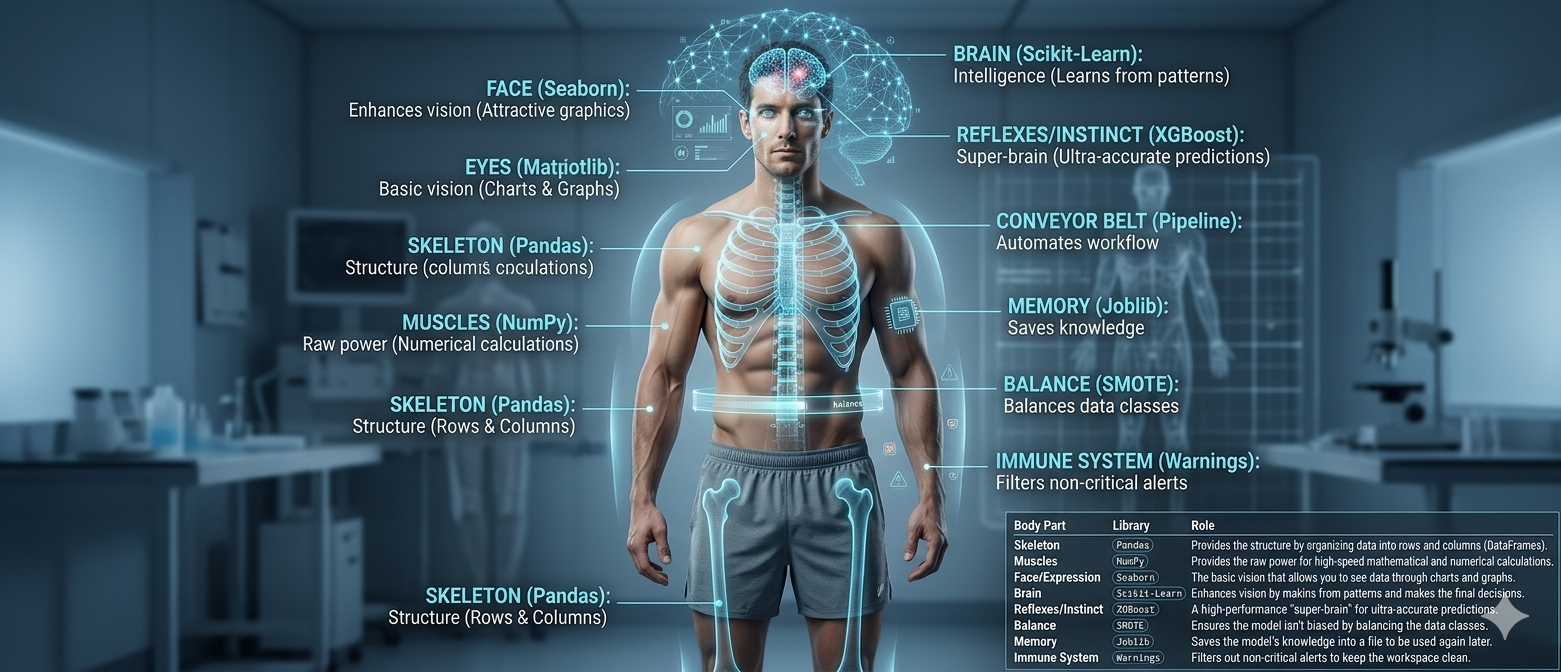

<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="purple">2 : Exploratory Data Analysis (EDA) : Data</font></b></h2>
    </td>
  </tr>
</table>

<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">2.1 : Loading Data</font></b></h2>
    </td>
  </tr>
</table>

In [5]:
df = pd.read_csv('GiveMeSomeCredit.csv', index_col=0)

<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">2.2 : Data Exploration</font></b></h2>
    </td>
  </tr>
</table>

In [6]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21128 entries, 1 to 21128
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      21128 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  21128 non-null  float64
 2   age                                   21128 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  21128 non-null  int64  
 4   DebtRatio                             21128 non-null  float64
 5   MonthlyIncome                         16882 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       21128 non-null  int64  
 7   NumberOfTimes90DaysLate               21128 non-null  int64  
 8   NumberRealEstateLoansOrLines          21128 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  21128 non-null  int64  
 10  NumberOfDependents                    20547 non-null  float64
dtypes: float64(4), int64

<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">2.3 : Descriptive statistics</font></b></h2>
    </td>
  </tr>
</table>




In [8]:
df.describe().round(2)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,21128.00,21128.00,21128.00,21128.00,21128.00,16882.00,21128.00,21128.00,21128.00,21128.00,20547.00
mean,0.06,4.86,52.28,0.40,351.93,6576.84,8.40,0.25,1.01,0.22,0.75
std,0.25,205.54,14.78,3.92,1744.52,6856.68,5.09,3.90,1.10,3.88,1.12
min,0.00,0.00,21.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.17,3400.00,5.00,0.00,0.00,0.00,0.00
50%,0.00,0.16,52.00,0.00,0.37,5398.50,8.00,0.00,1.00,0.00,0.00
75%,0.00,0.56,63.00,0.00,0.88,8200.00,11.00,0.00,2.00,0.00,1.00
max,1.00,22198.00,103.00,98.00,168835.00,251608.00,54.00,98.00,26.00,98.00,20.00


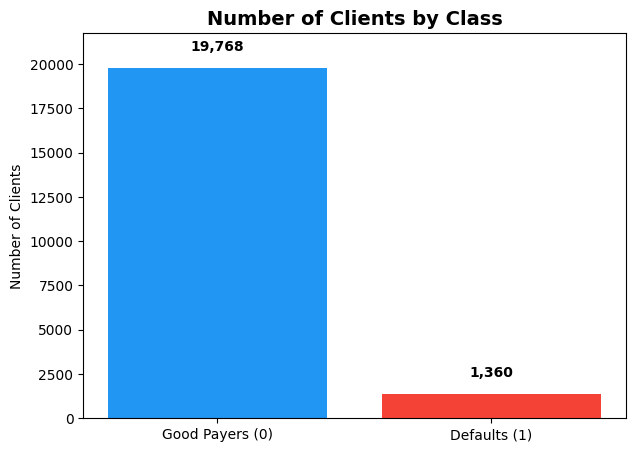

Imbalance Ratio: 14.5 to 1


In [9]:
target_counts = df['SeriousDlqin2yrs'].value_counts()
plt.figure(figsize=(7, 5))
colors = ['#2196F3', '#F44336'] # Bleu (0) et Rouge (1)

bars = plt.bar(['Good Payers (0)', 'Defaults (1)'], target_counts.values, color=colors)

#  Adding numbers above the bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1000,
             f'{int(height):,}', ha='center', fontweight='bold')

# Graphic dressing

plt.title('Number of Clients by Class', fontsize=14, fontweight='bold')
plt.ylabel('Number of Clients')
plt.ylim(0, max(target_counts.values) * 1.1) # Provide space for the text
plt.show()

print(f"Imbalance Ratio: {target_counts[0]/target_counts[1]:.1f} to 1")

Missing Values Summary:
                    Missing Count  Percentage (%)
MonthlyIncome                4246           20.10
NumberOfDependents            581            2.75


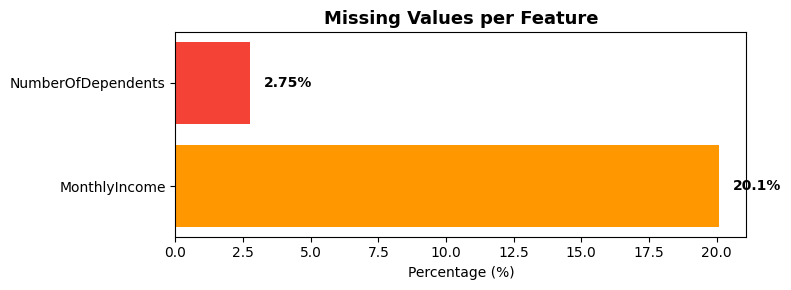

In [10]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

# Create a summary DataFrame
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

print("Missing Values Summary:")
print(missing_df)

# Horizontal Bar Chart
fig, ax = plt.subplots(figsize=(8, 3))
colors = ['#FF9800', '#F44336'] # Orange and Red

bars = ax.barh(missing_df.index, missing_df['Percentage (%)'], color=colors)
ax.set_xlabel('Percentage (%)')
ax.set_title('Missing Values per Feature', fontsize=13, fontweight='bold')

# Add labels on the bars
for bar, val in zip(bars, missing_df['Percentage (%)']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()


<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="purple">3 : Data Preprocessing (Prétraitement des Données)</font></b></h2>
    </td>
  </tr>
</table>

<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">3.1 : Copy of the dataset</font></b></h2>
    </td>
  </tr>
</table>




In [11]:
data = df.copy()


<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">3.2 : Imputation by the median</font></b></h2>
    </td>
  </tr>
</table>




In [12]:
for col in ['MonthlyIncome', 'NumberOfDependents']:
    median_val = data[col].median()
    data[col].fillna(median_val, inplace=True)
    print(f" {col} : {data[col].isnull().sum()} missing values (médiane = {median_val:.0f})")

 MonthlyIncome : 0 missing values (médiane = 5398)
 NumberOfDependents : 0 missing values (médiane = 0)


<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">3.3 : Capping of outliers (99th percentile)</font></b></h2>
    </td>
  </tr>
</table>




In [13]:
# List of columns to treat for outliers
outlier_cols = ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome',
                'NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse',
                'NumberOfTime60-89DaysPastDueNotWorse']

# Apply 99th percentile capping (Winsorization)
for col in outlier_cols:
    cap = data[col].quantile(0.99)
    data[col] = data[col].clip(upper=cap)

# Verification prints
print("\n Outlier capping completed.")
print(f"\nFinal Shape: {data.shape}")
print(f"Missing Values: {data.isnull().sum().sum()}")


 Outlier capping completed.

Final Shape: (21128, 11)
Missing Values: 0



<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">3.4 : Separate features and target variable</font></b></h2>
    </td>
  </tr>
</table>




In [14]:
X = data.drop('SeriousDlqin2yrs', axis=1)
y = data['SeriousDlqin2yrs']

print(f"Features: {X.shape[1]} columns")
print(f"Total Samples: {X.shape[0]:,} rows")
print(f"\nFeatures being used:")
for col in X.columns:
    print(f"  - {col}")

Features: 10 columns
Total Samples: 21,128 rows

Features being used:
  - RevolvingUtilizationOfUnsecuredLines
  - age
  - NumberOfTime30-59DaysPastDueNotWorse
  - DebtRatio
  - MonthlyIncome
  - NumberOfOpenCreditLinesAndLoans
  - NumberOfTimes90DaysLate
  - NumberRealEstateLoansOrLines
  - NumberOfTime60-89DaysPastDueNotWorse
  - NumberOfDependents


<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">3.5 : Train/Test split</font></b></h2>
    </td>
  </tr>
</table>




In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train : {X_train.shape[0]:,} exemples")
print(f"Test  : {X_test.shape[0]:,} exemples")
print(f"\nDistribution train : {y_train.value_counts().to_dict()}")
print(f"Distribution test  : {y_test.value_counts().to_dict()}")

Train : 16,902 exemples
Test  : 4,226 exemples

Distribution train : {0: 15814, 1: 1088}
Distribution test  : {0: 3954, 1: 272}


<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">3.6 : Handling Class Imbalance with SMOTE</font></b></h2>
    </td>
  </tr>
</table>


In [16]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE :")
print(f"  Train : {X_train_sm.shape[0]:,} examples ({pd.Series(y_train_sm).value_counts().to_dict()})")


After SMOTE :
  Train : 31,628 examples ({0: 15814, 1: 15814})


<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="purple">4 : Model Training and Comparison</font></b></h2>
    </td>
  </tr>
</table>


<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">4.1 : Normalisation</font></b></h2>
    </td>
  </tr>
</table>




In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)


<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">4.2 : Initial model definition with default parameters




</font></b></h2>
    </td>
  </tr>
</table>




In [18]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', use_label_encoder=False, n_jobs=-1),
    'KNN':                 KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}



<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">
<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">4.3 : Training and evaluation
</font></b></h2>
    </td>
  </tr>
</table>







</font></b></h2>
    </td>
  </tr>
</table>




In [21]:
results = {}
for name, model in models.items():
    X_tr = X_train_scaled if name in ['Logistic Regression', 'KNN'] else X_train_sm
    X_te = X_test_scaled  if name in ['Logistic Regression', 'KNN'] else X_test

    model.fit(X_tr, y_train_sm)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    results[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'y_proba':  y_proba,
        'accuracy': accuracy_score(y_test, y_pred),
        'auc':      roc_auc_score(y_test, y_proba),
        'f1':       f1_score(y_test, y_pred),
        'ap':       average_precision_score(y_test, y_proba),
    }
    print(f" {name:<22} | AUC: {results[name]['auc']:.4f} | F1: {results[name]['f1']:.4f} | Acc: {results[name]['accuracy']:.4f}")


 Logistic Regression    | AUC: 0.8284 | F1: 0.2771 | Acc: 0.7617
 Random Forest          | AUC: 0.8088 | F1: 0.3210 | Acc: 0.8919
 XGBoost                | AUC: 0.7595 | F1: 0.2635 | Acc: 0.8810
 KNN                    | AUC: 0.7741 | F1: 0.2680 | Acc: 0.7738


<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="purple">5 : Comparative Analysis : Baseline Models</font></b></h2>
    </td>
  </tr>
</table>

<table bgcolor="#D3D3D3" width="100%">
  <tr><td align="left">
      <h2><b><font color="blue">5.1 : Performance Summary Table</font></b></h2>
  </td></tr>
</table>

In [22]:
results_df = pd.DataFrame({
    name: {
        'Accuracy':      f"{v['accuracy']:.4f}",
        'AUC-ROC':       f"{v['auc']:.4f}",
        'F1-Score':      f"{v['f1']:.4f}",
        'Avg Precision': f"{v['ap']:.4f}",
    }
    for name, v in results.items()
}).T

results_df.index.name = 'Model'
print("=== Baseline Model Comparison ===")
print(results_df.to_string())

=== Baseline Model Comparison ===
                    Accuracy AUC-ROC F1-Score Avg Precision
Model                                                      
Logistic Regression   0.7617  0.8284   0.2771        0.3068
Random Forest         0.8919  0.8088   0.3210        0.2188
XGBoost               0.8810  0.7595   0.2635        0.1890
KNN                   0.7738  0.7741   0.2680        0.1714


<table bgcolor="#D3D3D3" width="100%">
  <tr><td align="left">
      <h2><b><font color="blue">5.2 : Performance Bar Charts</font></b></h2>
  </td></tr>
</table>

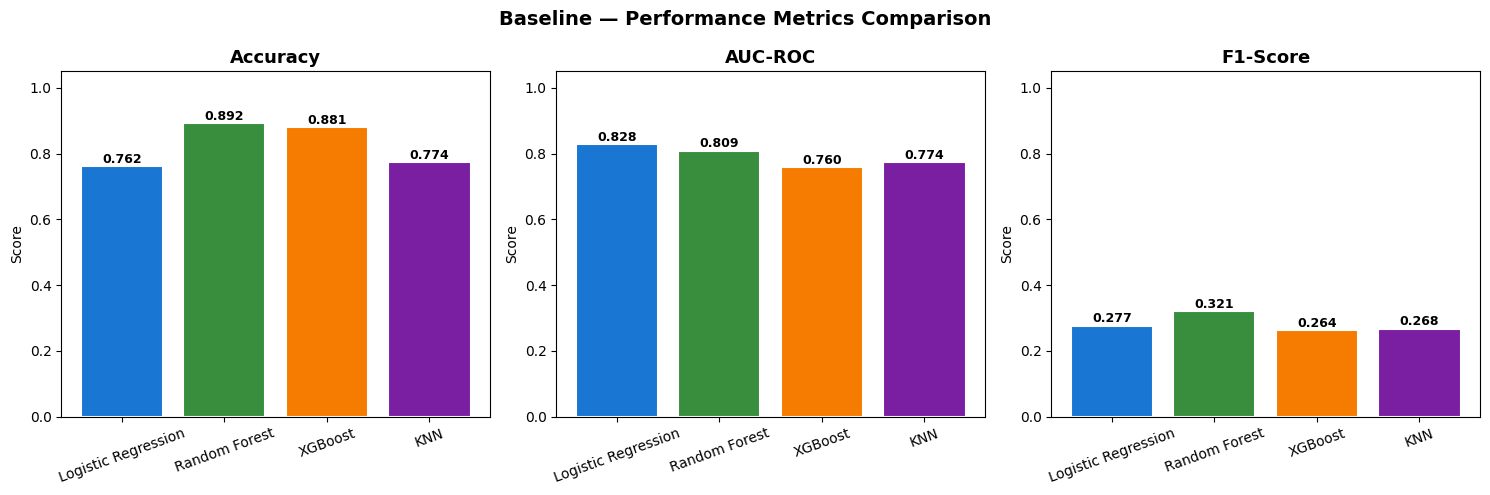

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics       = ['accuracy', 'auc', 'f1']
metric_labels = ['Accuracy', 'AUC-ROC', 'F1-Score']
colors        = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2']
model_names   = list(results.keys())

for ax, metric, label in zip(axes, metrics, metric_labels):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Baseline — Performance Metrics Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


<table bgcolor="#D3D3D3" width="100%">
  <tr><td align="left">
      <h2><b><font color="blue">5.3 : ROC &amp; Precision-Recall Curves</font></b></h2>
  </td></tr>
</table>

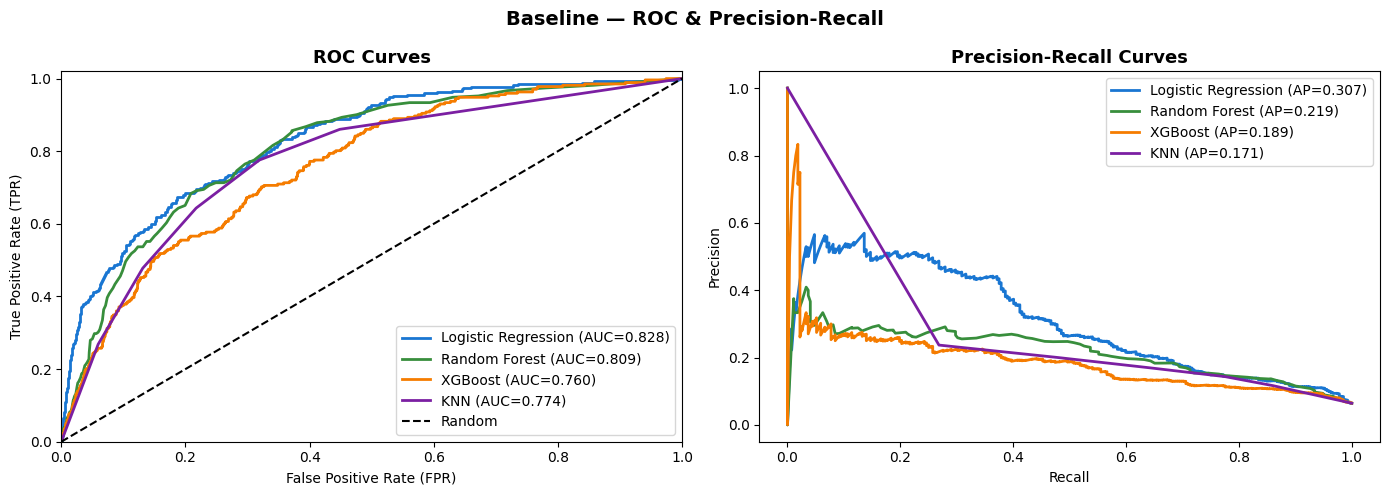

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_roc = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2']

# ROC Curve
ax = axes[0]
for (name, v), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, v['y_proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={v['auc']:.3f})", color=color, lw=2)
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random')
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR)')
ax.set_title('ROC Curves', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

# Precision-Recall Curve
ax = axes[1]
for (name, v), color in zip(results.items(), colors_roc):
    precision, recall, _ = precision_recall_curve(y_test, v['y_proba'])
    ax.plot(recall, precision, label=f"{name} (AP={v['ap']:.3f})", color=color, lw=2)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')

plt.suptitle('Baseline — ROC & Precision-Recall', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


<table bgcolor="#D3D3D3" width="100%">
  <tr><td align="left">
      <h2><b><font color="blue">5.4 : Confusion Matrices (Best Baseline vs Logistic Regression)</font></b></h2>
  </td></tr>
</table>

Best baseline model (by AUC): Logistic Regression


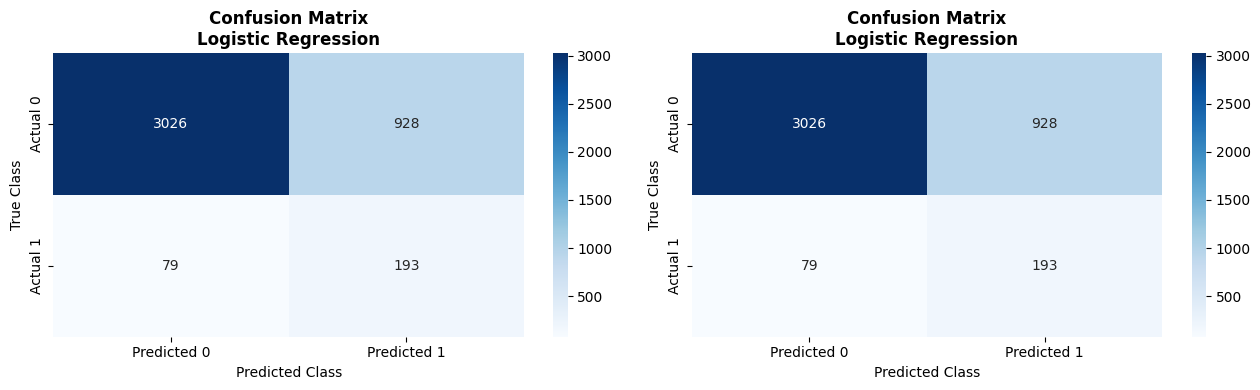

In [25]:
best_baseline_name = max(results, key=lambda x: results[x]['auc'])
print(f"Best baseline model (by AUC): {best_baseline_name}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (name, v) in zip(axes, [
    (best_baseline_name, results[best_baseline_name]),
    ('Logistic Regression', results['Logistic Regression'])
]):
    cm = confusion_matrix(y_test, v['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    ax.set_title(f'Confusion Matrix\n{name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Class')
    ax.set_xlabel('Predicted Class')

plt.tight_layout()
plt.show()


<table bgcolor="#D3D3D3" width="100%">
  <tr><td align="left">
      <h2><b><font color="blue">5.5 : Feature Importance : Logistic Regression</font></b></h2>
  </td></tr>
</table>

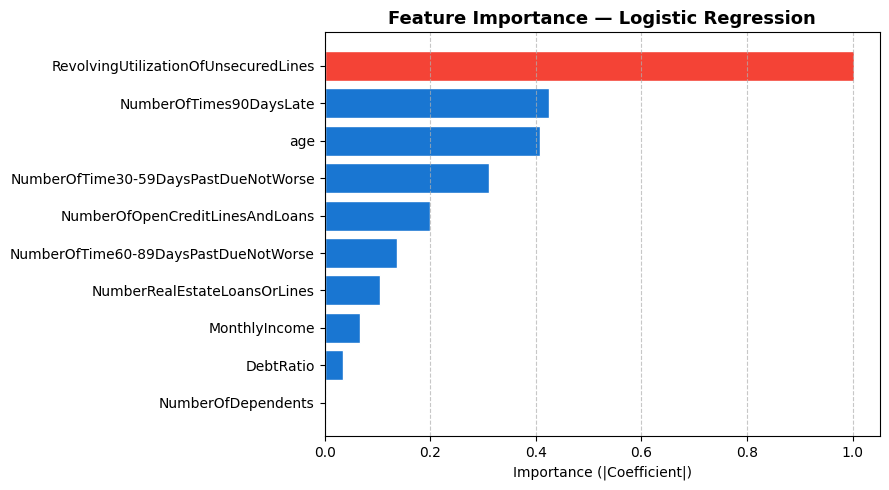


Top 5 Most Important Features:
  RevolvingUtilizationOfUnsecuredLines          1.0016
  NumberOfTimes90DaysLate                       0.4240
  age                                           0.4088
  NumberOfTime30-59DaysPastDueNotWorse          0.3118
  NumberOfOpenCreditLinesAndLoans               0.1990


In [26]:
log_model = results['Logistic Regression']['model']
feat_imp  = pd.Series(log_model.coef_[0], index=X.columns).abs().sort_values(ascending=True)

plt.figure(figsize=(9, 5))
colors_imp = ['#F44336' if v == feat_imp.max() else '#1976D2' for v in feat_imp.values]
plt.barh(feat_imp.index, feat_imp.values, color=colors_imp, edgecolor='white')
plt.xlabel('Importance (|Coefficient|)')
plt.title('Feature Importance — Logistic Regression', fontsize=13, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
for feat, val in feat_imp.sort_values(ascending=False).head(5).items():
    print(f"  {feat:<45} {val:.4f}")


<table bgcolor="#D3D3D3" width="100%">
  <tr><td align="left">
      <h2><b><font color="purple">6 : Model Optimization : XGBoost GridSearchCV</font></b></h2>
  </td></tr>
</table>

<table bgcolor="#D3D3D3" width="100%">
  <tr><td align="left">
      <h2><b><font color="blue">6.1 : Hyperparameter Tuning (GridSearchCV)</font></b></h2>
  </td></tr>
</table>

In [27]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample':     [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    verbose=1
)

grid_search.fit(X_train_sm, y_train_sm)  # tree-based model → no scaling needed

print(f"Best AUC (CV): {grid_search.best_score_:.4f}")
print(f"Best Parameters: {grid_search.best_params_}")

best_xgb = grid_search.best_estimator_


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best AUC (CV): 0.9708
Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


<table bgcolor="#D3D3D3" width="100%">
  <tr><td align="left">
      <h2><b><font color="blue">6.2 : Evaluate XGBoost (Optimized) on Test Set</font></b></h2>
  </td></tr>
</table>

In [28]:
y_pred_opt  = best_xgb.predict(X_test)
y_proba_opt = best_xgb.predict_proba(X_test)[:, 1]

# Add to results WITHOUT overwriting the baseline XGBoost
results['XGBoost (Optimized)'] = {
    'model':    best_xgb,
    'y_pred':   y_pred_opt,
    'y_proba':  y_proba_opt,
    'accuracy': accuracy_score(y_test, y_pred_opt),
    'auc':      roc_auc_score(y_test, y_proba_opt),
    'f1':       f1_score(y_test, y_pred_opt),
    'ap':       average_precision_score(y_test, y_proba_opt),
}

print(f"XGBoost (Optimized) | "
      f"AUC: {results['XGBoost (Optimized)']['auc']:.4f} | "
      f"F1: {results['XGBoost (Optimized)']['f1']:.4f} | "
      f"Acc: {results['XGBoost (Optimized)']['accuracy']:.4f}")
print(f"\nAll models in results: {list(results.keys())}")


XGBoost (Optimized) | AUC: 0.7825 | F1: 0.2630 | Acc: 0.8859

All models in results: ['Logistic Regression', 'Random Forest', 'XGBoost', 'KNN', 'XGBoost (Optimized)']


<table bgcolor="#D3D3D3" width="100%">
  <tr><td align="left">
      <h2><b><font color="purple">7 : Final Comparison — All Models &amp; Champion Selection</font></b></h2>
  </td></tr>
</table>

<table bgcolor="#D3D3D3" width="100%">
  <tr><td align="left">
      <h2><b><font color="blue">7.1 : Full Performance Summary Table</font></b></h2>
  </td></tr>
</table>

In [29]:
final_df = pd.DataFrame({
    name: {
        'Accuracy':      round(v['accuracy'], 4),
        'AUC-ROC':       round(v['auc'],      4),
        'F1-Score':      round(v['f1'],       4),
        'Avg Precision': round(v['ap'],       4),
    }
    for name, v in results.items()
}).T
final_df.index.name = 'Model'

# Highlight the champion row (highest AUC)
champion_name = final_df['AUC-ROC'].astype(float).idxmax()
print("=" * 65)
print("           FINAL MODEL COMPARISON (all 5 models)")
print("=" * 65)
print(final_df.to_string())
print("=" * 65)
print(f"  CHAMPION  →  {champion_name}  (AUC = {final_df.loc[champion_name, 'AUC-ROC']})")
print("=" * 65)

           FINAL MODEL COMPARISON (all 5 models)
                     Accuracy  AUC-ROC  F1-Score  Avg Precision
Model                                                          
Logistic Regression    0.7617   0.8284    0.2771         0.3068
Random Forest          0.8919   0.8088    0.3210         0.2188
XGBoost                0.8810   0.7595    0.2635         0.1890
KNN                    0.7738   0.7741    0.2680         0.1714
XGBoost (Optimized)    0.8859   0.7825    0.2630         0.2029
  CHAMPION  →  Logistic Regression  (AUC = 0.8284)


<table bgcolor="#D3D3D3" width="100%">
  <tr><td align="left">
      <h2><b><font color="blue">7.2 : Final Performance Bar Charts (All Models)</font></b></h2>
  </td></tr>
</table>

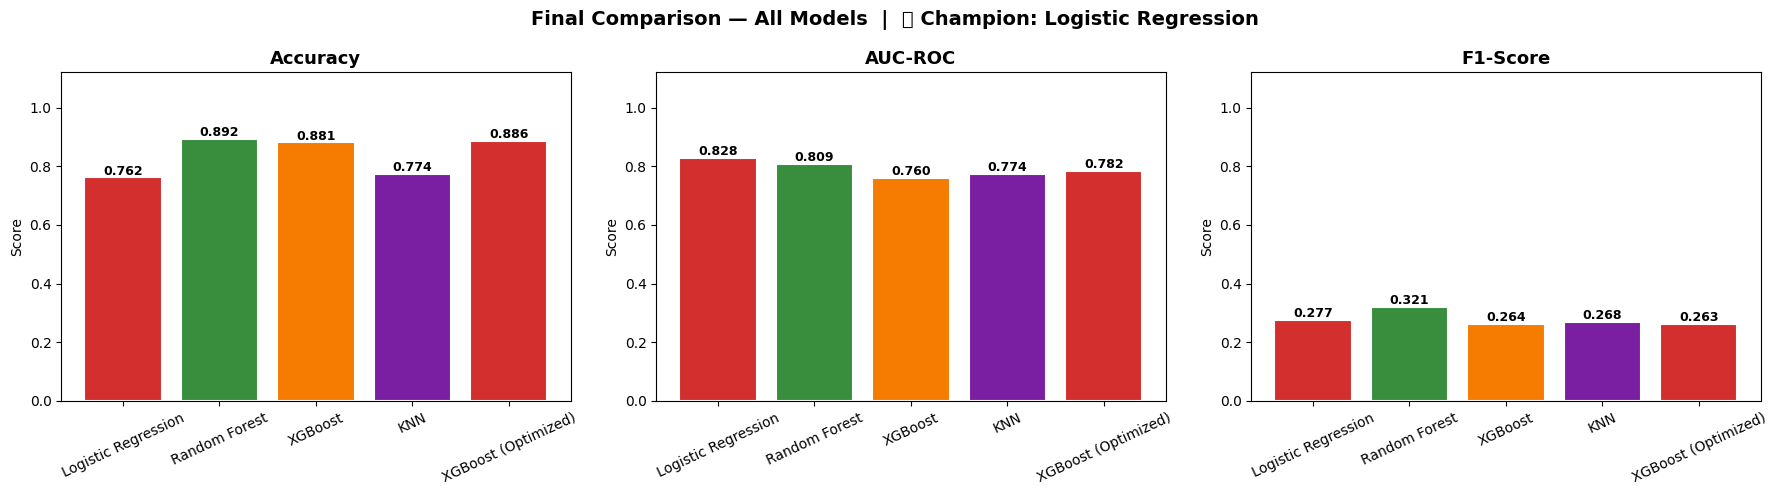

In [30]:
all_model_names = list(results.keys())
colors_all = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2', '#D32F2F']  # last = XGB Optimized

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics       = ['accuracy', 'auc', 'f1']
metric_labels = ['Accuracy', 'AUC-ROC', 'F1-Score']

for ax, metric, label in zip(axes, metrics, metric_labels):
    vals = [results[m][metric] for m in all_model_names]
    bar_colors = ['#D32F2F' if m == champion_name else c
                  for m, c in zip(all_model_names, colors_all)]
    bars = ax.bar(all_model_names, vals, color=bar_colors, edgecolor='white', linewidth=1.5)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.12)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle(f'Final Comparison — All Models  |  🏆 Champion: {champion_name}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


<table bgcolor="#D3D3D3" width="100%">
  <tr><td align="left">
      <h2><b><font color="blue">7.3 : Final ROC Curves (All Models)</font></b></h2>
  </td></tr>
</table>

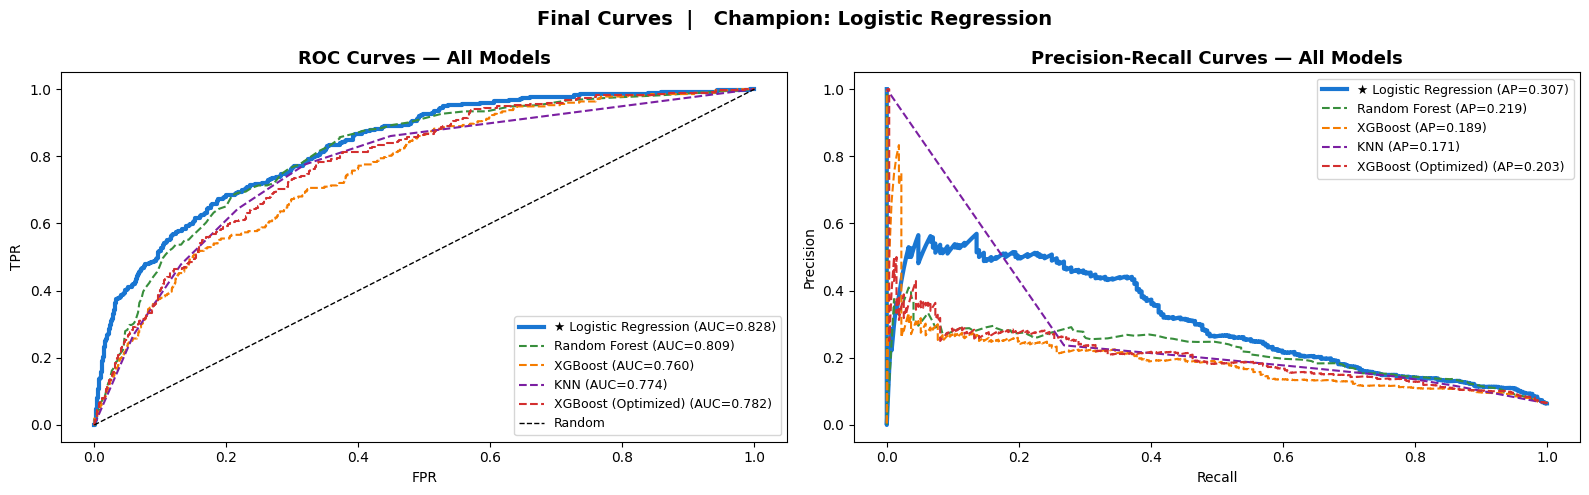

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ROC
ax = axes[0]
for (name, v), color in zip(results.items(), colors_all):
    lw = 3 if name == champion_name else 1.5
    ls = '-' if name == champion_name else '--'
    label = f"★ {name} (AUC={v['auc']:.3f})" if name == champion_name else f"{name} (AUC={v['auc']:.3f})"
    fpr, tpr, _ = roc_curve(y_test, v['y_proba'])
    ax.plot(fpr, tpr, label=label, color=color, lw=lw, linestyle=ls)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)

# Precision-Recall
ax = axes[1]
for (name, v), color in zip(results.items(), colors_all):
    lw = 3 if name == champion_name else 1.5
    ls = '-' if name == champion_name else '--'
    label = f"★ {name} (AP={v['ap']:.3f})" if name == champion_name else f"{name} (AP={v['ap']:.3f})"
    precision, recall, _ = precision_recall_curve(y_test, v['y_proba'])
    ax.plot(recall, precision, label=label, color=color, lw=lw, linestyle=ls)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)

plt.suptitle(f'Final Curves  |   Champion: {champion_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [33]:
import joblib
from google.colab import drive

# ── Mount Google Drive ───────────────────────────────────────────
drive.mount('/content/drive')

# ── Save the champion model and the scaler ───────────────────────
best_model = champion['model']

joblib.dump(best_model, '/content/drive/MyDrive/best_model.pkl')
joblib.dump(scaler,     '/content/drive/MyDrive/scaler.pkl')

print(f" Champion Model '{champion_name}' successfully saved as: best_model.pkl")
print(f" Scaler successfully saved as: scaler.pkl")

Mounted at /content/drive
 Champion Model 'Logistic Regression' successfully saved as: best_model.pkl
 Scaler successfully saved as: scaler.pkl
